import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Smart Room Occupancy Estimation

## Stage 3: Data Understanding and Exploratory Data Analysis

**Dataset:** Room Occupancy Estimation  
**Target Variable:** Room_Occupancy_Count  
**ML Task:** Multiclass Classification

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
DATA_PATH = Path("../data/raw/Occupancy_Estimation.csv")

In [3]:
df = pd.read_csv(DATA_PATH)

df.head()

,Date,Time,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
0,2017/12/22,10:49:41,24.94,24.75,24.56,25.38,121,34,53,40,0.08,0.19,0.06,0.06,390,0.769231,0,0,1
1,2017/12/22,10:50:12,24.94,24.75,24.56,25.44,121,33,53,40,0.93,0.05,0.06,0.06,390,0.646154,0,0,1
2,2017/12/22,10:50:42,25.00,24.75,24.50,25.44,121,34,53,40,0.43,0.11,0.08,0.06,390,0.519231,0,0,1
3,2017/12/22,10:51:13,25.00,24.75,24.56,25.44,121,34,53,40,0.41,0.10,0.10,0.09,390,0.388462,0,0,1
4,2017/12/22,10:51:44,25.00,24.75,24.56,25.44,121,34,54,40,0.18,0.06,0.06,0.06,390,0.253846,0,0,1


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 10129
Number of columns: 19


In [5]:
df.columns.tolist()

['Date',
 'Time',
 'S1_Temp',
 'S2_Temp',
 'S3_Temp',
 'S4_Temp',
 'S1_Light',
 'S2_Light',
 'S3_Light',
 'S4_Light',
 'S1_Sound',
 'S2_Sound',
 'S3_Sound',
 'S4_Sound',
 'S5_CO2',
 'S5_CO2_Slope',
 'S6_PIR',
 'S7_PIR',
 'Room_Occupancy_Count']

In [6]:
df.dtypes

Date                        str
Time                        str
S1_Temp                 float64
S2_Temp                 float64
S3_Temp                 float64
S4_Temp                 float64
S1_Light                  int64
S2_Light                  int64
S3_Light                  int64
S4_Light                  int64
S1_Sound                float64
S2_Sound                float64
S3_Sound                float64
S4_Sound                float64
S5_CO2                    int64
S5_CO2_Slope            float64
S6_PIR                    int64
S7_PIR                    int64
Room_Occupancy_Count      int64
dtype: object

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10129 entries, 0 to 10128
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  10129 non-null  str    
 1   Time                  10129 non-null  str    
 2   S1_Temp               10129 non-null  float64
 3   S2_Temp               10129 non-null  float64
 4   S3_Temp               10129 non-null  float64
 5   S4_Temp               10129 non-null  float64
 6   S1_Light              10129 non-null  int64  
 7   S2_Light              10129 non-null  int64  
 8   S3_Light              10129 non-null  int64  
 9   S4_Light              10129 non-null  int64  
 10  S1_Sound              10129 non-null  float64
 11  S2_Sound              10129 non-null  float64
 12  S3_Sound              10129 non-null  float64
 13  S4_Sound              10129 non-null  float64
 14  S5_CO2                10129 non-null  int64  
 15  S5_CO2_Slope          10129 no

In [8]:
missing_values = df.isnull().sum()

missing_values

Date                    0
Time                    0
S1_Temp                 0
S2_Temp                 0
S3_Temp                 0
S4_Temp                 0
S1_Light                0
S2_Light                0
S3_Light                0
S4_Light                0
S1_Sound                0
S2_Sound                0
S3_Sound                0
S4_Sound                0
S5_CO2                  0
S5_CO2_Slope            0
S6_PIR                  0
S7_PIR                  0
Room_Occupancy_Count    0
dtype: int64

In [9]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [10]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [11]:
df.describe()

,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
count,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.00000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000
mean,25.454012,25.546059,25.056621,25.754125,25.445059,26.01629,34.248494,13.220259,0.168178,0.120066,0.158119,0.103840,460.860401,-0.004830,0.090137,0.079574,0.398559
std,0.351351,0.586325,0.427283,0.356434,51.011264,67.30417,58.400744,19.602219,0.316709,0.266503,0.413637,0.120683,199.964940,1.164990,0.286392,0.270645,0.893633
min,24.940000,24.750000,24.440000,24.940000,0.000000,0.00000,0.000000,0.000000,0.060000,0.040000,0.040000,0.050000,345.000000,-6.296154,0.000000,0.000000,0.000000
25%,25.190000,25.190000,24.690000,25.440000,0.000000,0.00000,0.000000,0.000000,0.070000,0.050000,0.060000,0.060000,355.000000,-0.046154,0.000000,0.000000,0.000000
50%,25.380000,25.380000,24.940000,25.750000,0.000000,0.00000,0.000000,0.000000,0.080000,0.050000,0.060000,0.080000,360.000000,0.000000,0.000000,0.000000,0.000000
75%,25.630000,25.630000,25.380000,26.000000,12.000000,14.00000,50.000000,22.000000,0.080000,0.060000,0.070000,0.100000,465.000000,0.000000,0.000000,0.000000,0.000000
max,26.380000,29.000000,26.190000,26.560000,165.000000,258.00000,280.000000,74.000000,3.880000,3.440000,3.670000,3.400000,1270.000000,8.980769,1.000000,1.000000,3.000000


In [12]:
df.describe(include="all")

,Date,Time,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
count,10129,10129,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.00000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000
unique,7,10129,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2017/12/23,10:49:41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,2779,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,25.454012,25.546059,25.056621,25.754125,25.445059,26.01629,34.248494,13.220259,0.168178,0.120066,0.158119,0.103840,460.860401,-0.004830,0.090137,0.079574,0.398559
std,NaN,NaN,0.351351,0.586325,0.427283,0.356434,51.011264,67.30417,58.400744,19.602219,0.316709,0.266503,0.413637,0.120683,199.964940,1.164990,0.286392,0.270645,0.893633
min,NaN,NaN,24.940000,24.750000,24.440000,24.940000,0.000000,0.00000,0.000000,0.000000,0.060000,0.040000,0.040000,0.050000,345.000000,-6.296154,0.000000,0.000000,0.000000
25%,NaN,NaN,25.190000,25.190000,24.690000,25.440000,0.000000,0.00000,0.000000,0.000000,0.070000,0.050000,0.060000,0.060000,355.000000,-0.046154,0.000000,0.000000,0.000000
50%,NaN,NaN,25.380000,25.380000,24.940000,25.750000,0.000000,0.00000,0.000000,0.000000,0.080000,0.050000,0.060000,0.080000,360.000000,0.000000,0.000000,0.000000,0.000000
75%,NaN,NaN,25.630000,25.630000,25.380000,26.000000,12.000000,14.00000,50.000000,22.000000,0.080000,0.060000,0.070000,0.100000,465.000000,0.000000,0.000000,0.000000,0.000000


In [13]:
target_counts = df["Room_Occupancy_Count"].value_counts().sort_index()

target_counts

Room_Occupancy_Count
0    8228
1     459
2     748
3     694
Name: count, dtype: int64

In [14]:
target_percentages = (
    df["Room_Occupancy_Count"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

target_percentages

Room_Occupancy_Count
0    81.232106
1     4.531543
2     7.384737
3     6.851614
Name: proportion, dtype: float64

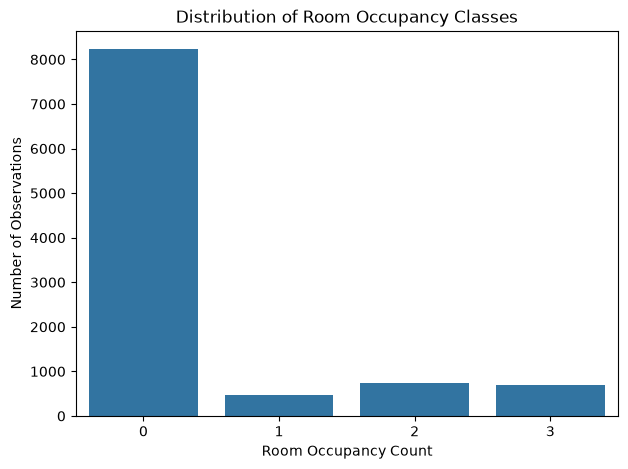

In [15]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Room_Occupancy_Count"
)

plt.title("Distribution of Room Occupancy Classes")
plt.xlabel("Room Occupancy Count")
plt.ylabel("Number of Observations")

plt.show()

In [16]:
class_distribution = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages.round(2)
})

class_distribution

,Count,Percentage
Room_Occupancy_Count,,
0,8228,81.23
1,459,4.53
2,748,7.38
3,694,6.85


In [17]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

numeric_columns

['S1_Temp',
 'S2_Temp',
 'S3_Temp',
 'S4_Temp',
 'S1_Light',
 'S2_Light',
 'S3_Light',
 'S4_Light',
 'S1_Sound',
 'S2_Sound',
 'S3_Sound',
 'S4_Sound',
 'S5_CO2',
 'S5_CO2_Slope',
 'S6_PIR',
 'S7_PIR',
 'Room_Occupancy_Count']

In [18]:
feature_columns = [
    col for col in numeric_columns
    if col != "Room_Occupancy_Count"
]

feature_columns

['S1_Temp',
 'S2_Temp',
 'S3_Temp',
 'S4_Temp',
 'S1_Light',
 'S2_Light',
 'S3_Light',
 'S4_Light',
 'S1_Sound',
 'S2_Sound',
 'S3_Sound',
 'S4_Sound',
 'S5_CO2',
 'S5_CO2_Slope',
 'S6_PIR',
 'S7_PIR']

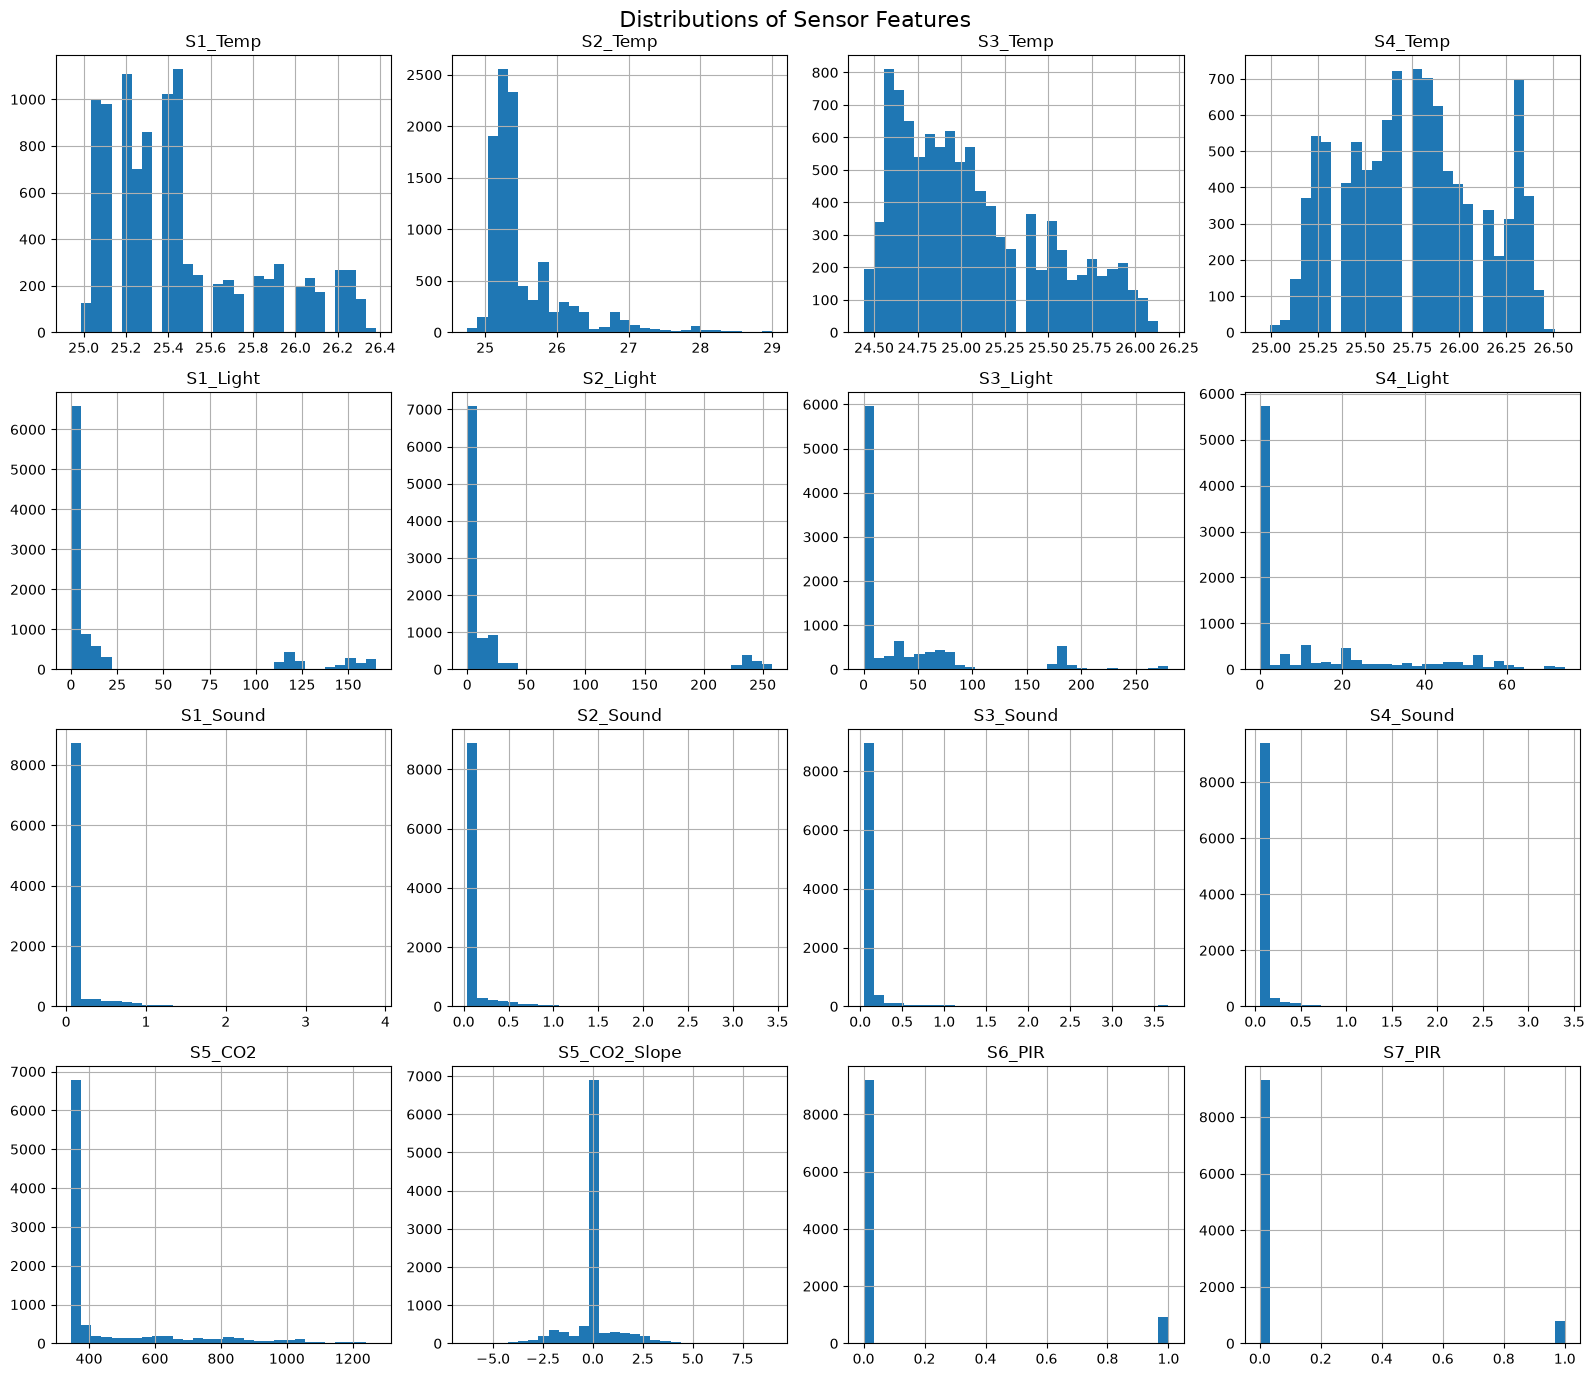

In [19]:
df[feature_columns].hist(
    figsize=(16, 14),
    bins=30
)

plt.suptitle("Distributions of Sensor Features", fontsize=16)

plt.tight_layout()
plt.show()

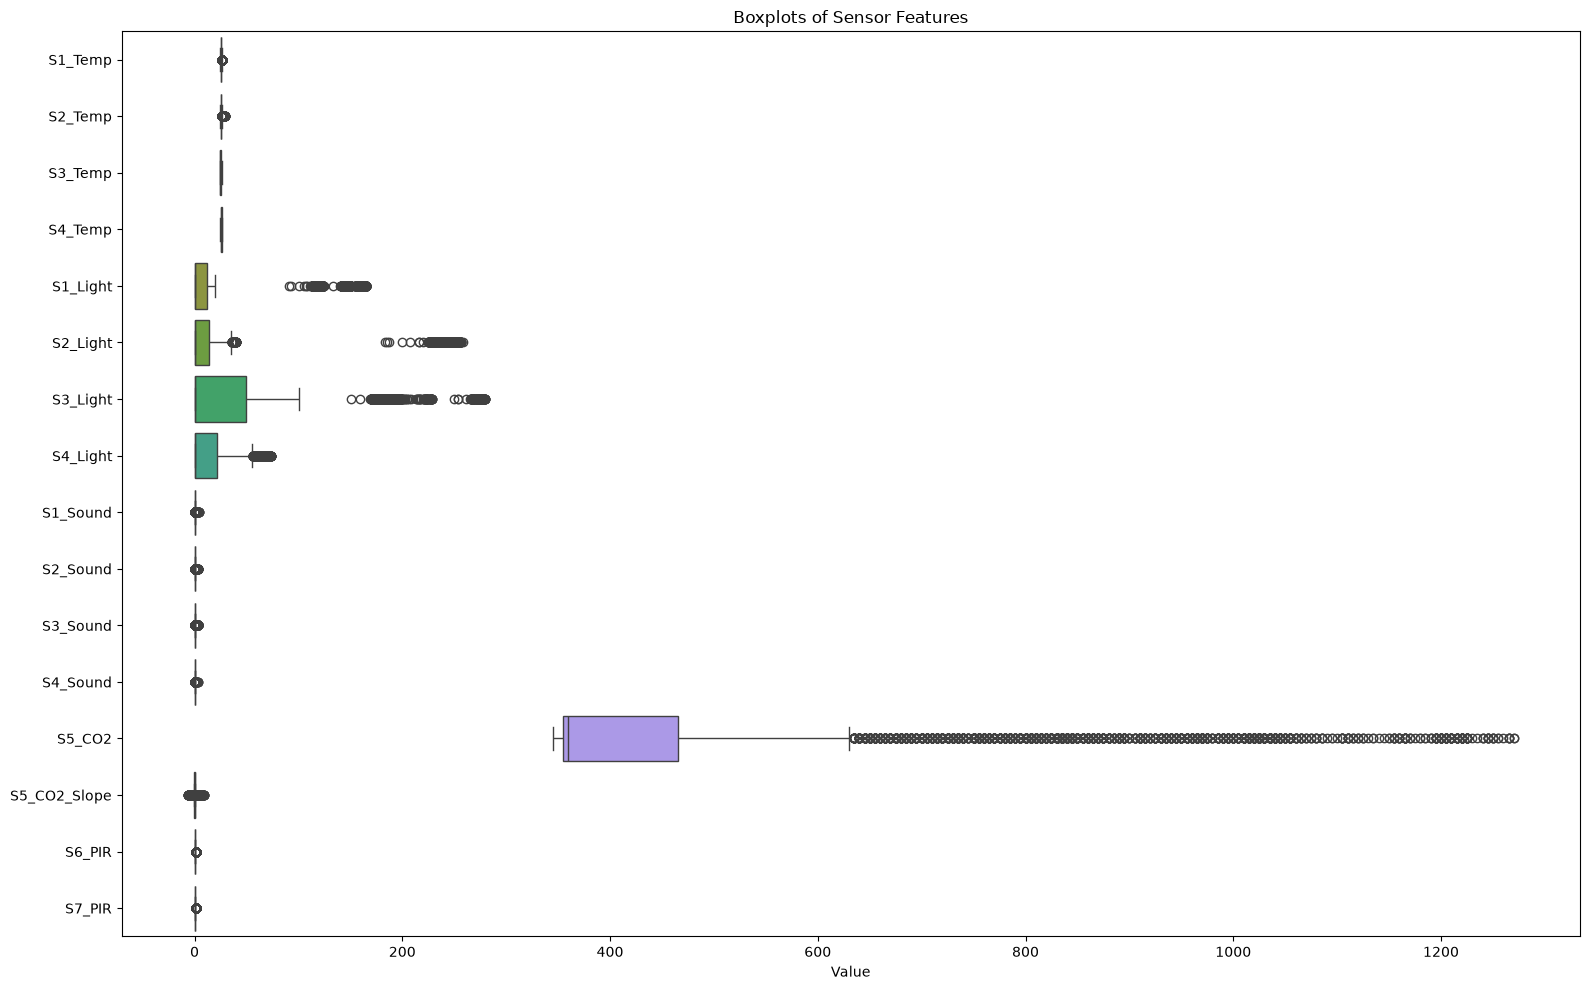

In [20]:
plt.figure(figsize=(16, 10))

sns.boxplot(
    data=df[feature_columns],
    orient="h"
)

plt.title("Boxplots of Sensor Features")
plt.xlabel("Value")

plt.tight_layout()
plt.show()

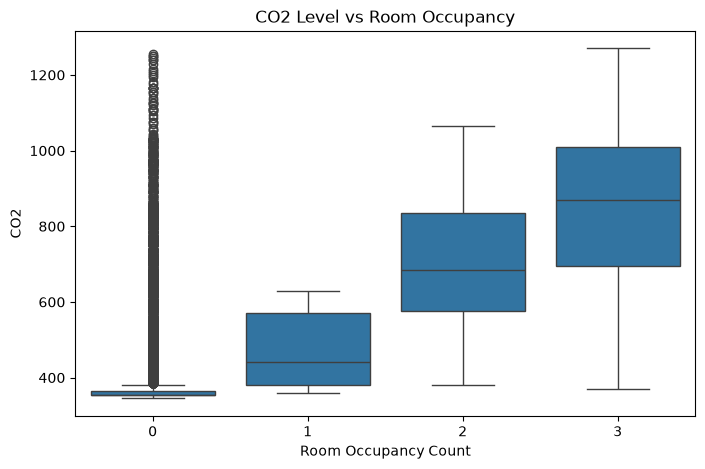

In [21]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Room_Occupancy_Count",
    y="S5_CO2"
)

plt.title("CO2 Level vs Room Occupancy")
plt.xlabel("Room Occupancy Count")
plt.ylabel("CO2")

plt.show()

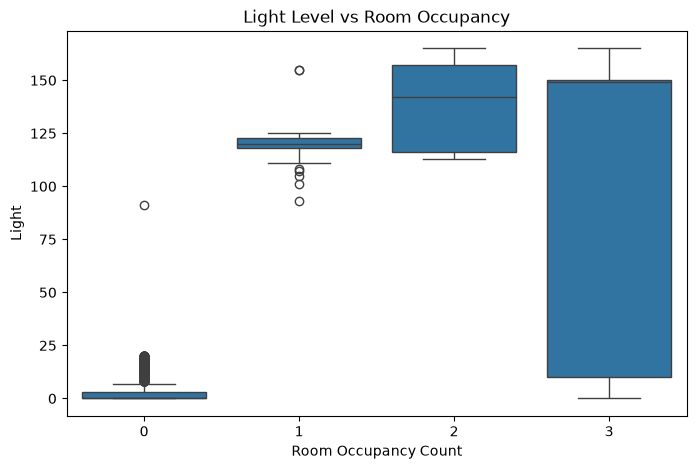

In [22]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Room_Occupancy_Count",
    y="S1_Light"
)

plt.title("Light Level vs Room Occupancy")
plt.xlabel("Room Occupancy Count")
plt.ylabel("Light")

plt.show()

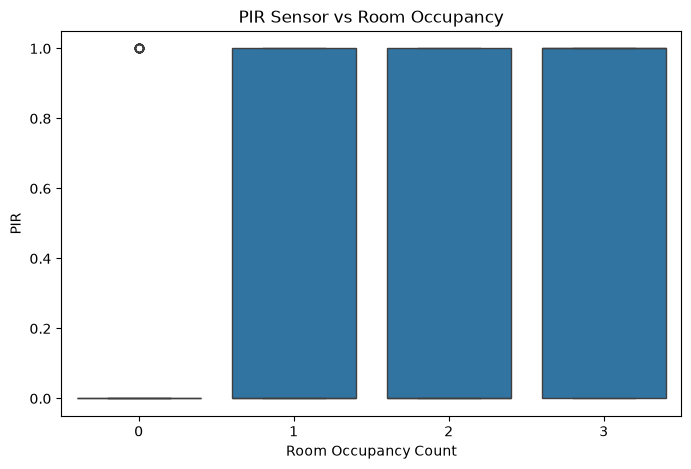

In [23]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Room_Occupancy_Count",
    y="S6_PIR"
)

plt.title("PIR Sensor vs Room Occupancy")
plt.xlabel("Room Occupancy Count")
plt.ylabel("PIR")

plt.show()

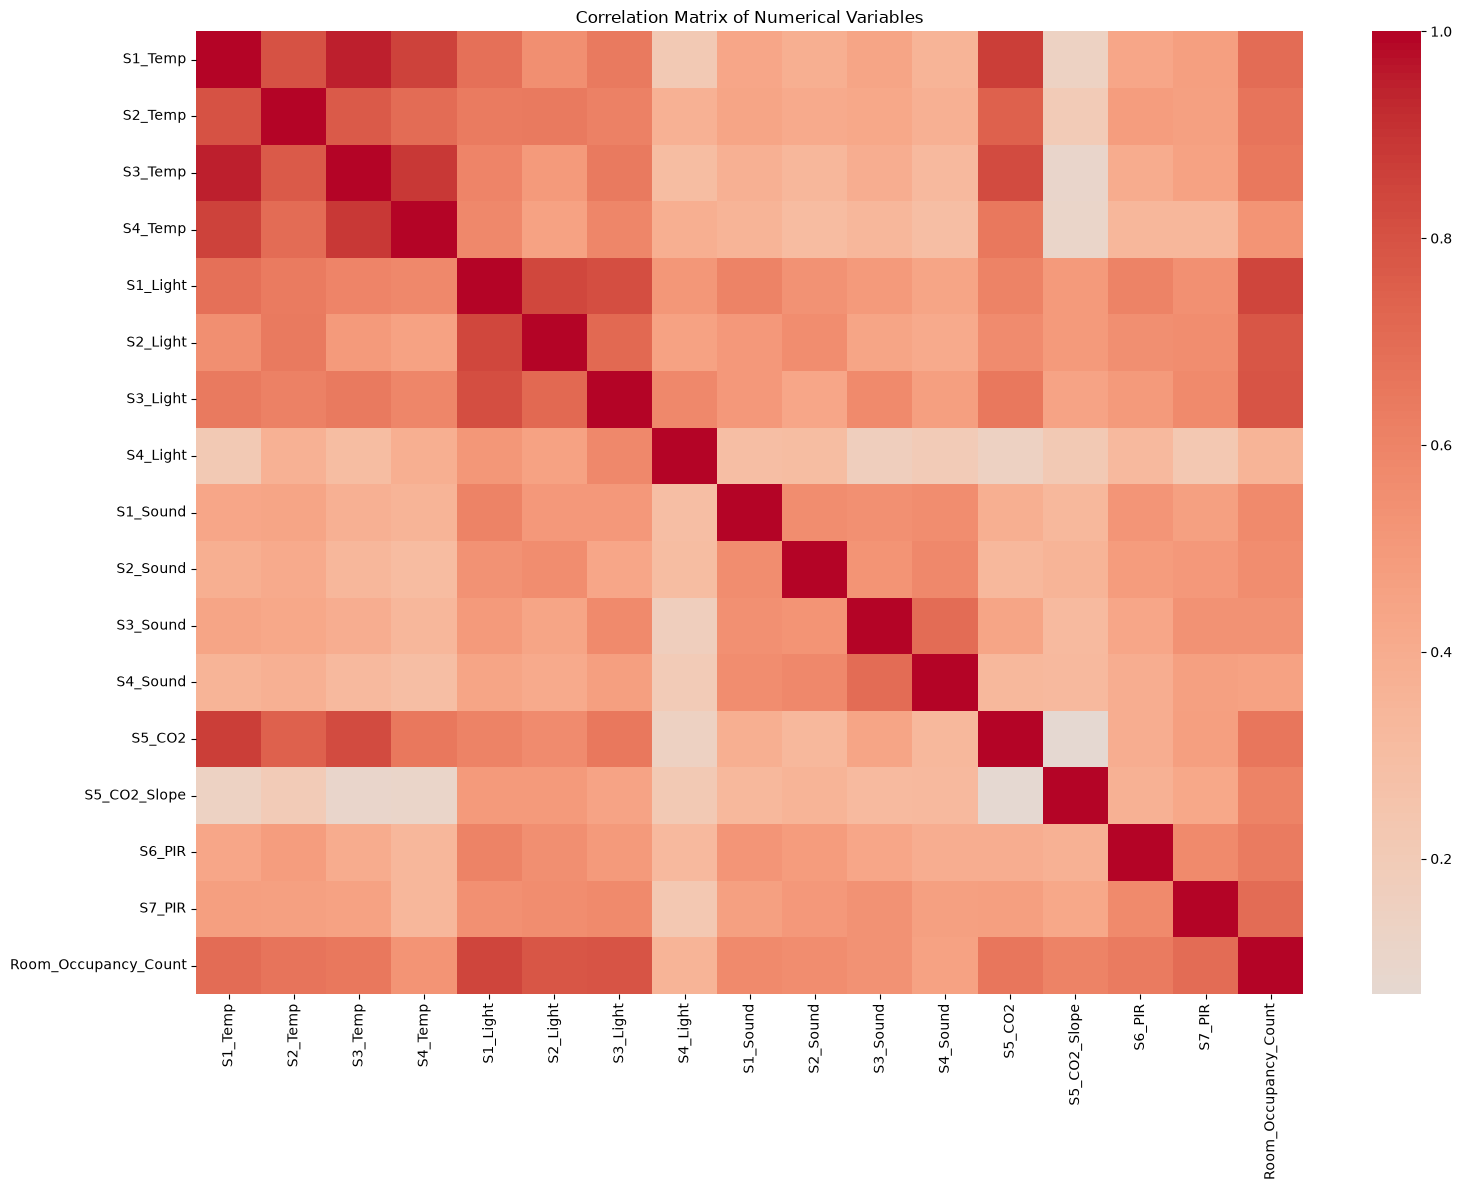

In [24]:
correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    annot=False,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Variables")

plt.tight_layout()
plt.show()

In [25]:
target_correlations = (
    correlation_matrix["Room_Occupancy_Count"]
    .sort_values(ascending=False)
)

target_correlations

Room_Occupancy_Count    1.000000
S1_Light                0.849058
S3_Light                0.793081
S2_Light                0.788764
S1_Temp                 0.700868
S7_PIR                  0.695138
S2_Temp                 0.671263
S5_CO2                  0.660144
S3_Temp                 0.652047
S6_PIR                  0.633133
S5_CO2_Slope            0.601105
S1_Sound                0.573748
S2_Sound                0.557853
S3_Sound                0.531685
S4_Temp                 0.526509
S4_Sound                0.460287
S4_Light                0.355715
Name: Room_Occupancy_Count, dtype: float64

In [26]:
df[["Date", "Time"]].head(10)

,Date,Time
0,2017/12/22,10:49:41
1,2017/12/22,10:50:12
2,2017/12/22,10:50:42
3,2017/12/22,10:51:13
4,2017/12/22,10:51:44
5,2017/12/22,10:52:14
6,2017/12/22,10:52:45
7,2017/12/22,10:53:15
8,2017/12/22,10:53:46
9,2017/12/22,10:54:17


In [27]:
df[["Date", "Time"]].tail(10)

,Date,Time
10119,2018/01/11,08:55:34
10120,2018/01/11,08:56:04
10121,2018/01/11,08:56:35
10122,2018/01/11,08:57:06
10123,2018/01/11,08:57:36
10124,2018/01/11,08:58:07
10125,2018/01/11,08:58:37
10126,2018/01/11,08:59:08
10127,2018/01/11,08:59:39
10128,2018/01/11,09:00:09


In [28]:
df["DateTime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"]
)

df[["Date", "Time", "DateTime"]].head()

,Date,Time,DateTime
0,2017/12/22,10:49:41,2017-12-22 10:49:41
1,2017/12/22,10:50:12,2017-12-22 10:50:12
2,2017/12/22,10:50:42,2017-12-22 10:50:42
3,2017/12/22,10:51:13,2017-12-22 10:51:13
4,2017/12/22,10:51:44,2017-12-22 10:51:44


In [29]:
print("Start:", df["DateTime"].min())
print("End:", df["DateTime"].max())

Start: 2017-12-22 10:49:41
End: 2018-01-11 09:00:09


In [30]:
df["Hour"] = df["DateTime"].dt.hour
df["Minute"] = df["DateTime"].dt.minute

In [31]:
occupancy_by_hour = (
    df.groupby("Hour")["Room_Occupancy_Count"]
    .mean()
)

occupancy_by_hour

Hour
0     0.000000
1     0.000000
2     0.000000
3     0.000000
4     0.000000
5     0.000000
6     0.000000
7     0.000000
8     0.000000
9     0.000000
10    0.082353
11    0.552326
12    1.028571
13    1.546547
14    0.363112
15    0.808717
16    1.454348
17    1.735484
18    1.412527
19    0.880266
20    0.000000
21    0.000000
22    0.000000
23    0.000000
Name: Room_Occupancy_Count, dtype: float64

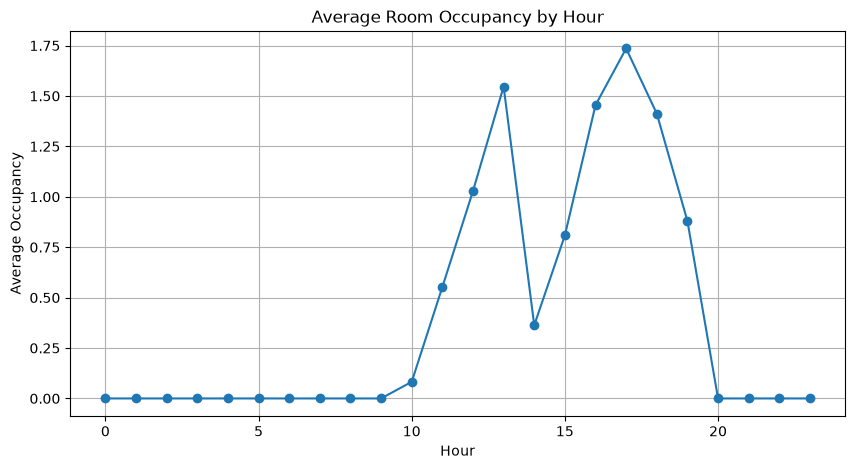

In [32]:
plt.figure(figsize=(10, 5))

occupancy_by_hour.plot(
    marker="o"
)

plt.title("Average Room Occupancy by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Occupancy")

plt.grid(True)

plt.show()

# EDA Findings Summary

## Dataset Structure
- The dataset contains 10,129 observations and 19 columns.
- There are 18 predictor variables and one target variable.
- The predictors mainly represent environmental sensor measurements.

## Missing Values
- No missing values were identified in the dataset.
- Therefore, missing-value imputation is not required.

## Duplicate Records
- No exact duplicate records were identified.

## Target Variable
- The target variable is `Room_Occupancy_Count`.
- The target contains four occupancy classes: 0, 1, 2, and 3.
- The class distribution was examined to determine whether class imbalance is present.

## Feature Distributions
- Sensor feature distributions were examined using descriptive statistics and histograms.
- Boxplots were used to investigate potential outliers.

## Feature Relationships
- Relationships between sensor measurements and room occupancy were investigated using boxplots and correlation analysis.

## Temporal Structure
- The dataset contains Date and Time information.
- The measurements are sequential and collected at short time intervals.
- Temporal structure must therefore be considered when creating training and testing sets.

## Data Leakage
- Random splitting may place temporally adjacent observations into both training and testing sets.
- A chronological split will therefore be considered during preprocessing to reduce the risk of temporal leakage.